In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [31]:
# Import local files
%load_ext autoreload
%autoreload 2
from training import get_semi_supervised_labels, SSLDataset, train_loop_labeled, train_loop_hard_pseudo_label, evaluate, evaluate_perclass
from plots import *
from cnn import CNN
from constants import short_labels, long_labels

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [7]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [8]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

## Fully Labeled Dataset
What kind of performance can we get if we leave all labels in the dataset?
This might be helpful just to view as an upper bound, like our best possible performance

In [9]:
cnn_labeled = CNN(n_channels, n_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_labeled.parameters(), lr=0.001)

train_history = train_loop_labeled(cnn_labeled, train_loader, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.24it/s]


Epoch 1/20 | Train Loss: 0.9465 | Val Loss: 0.8208 | Val Acc: 0.6830 | Val AUC: 0.8794


100%|██████████| 55/55 [00:04<00:00, 13.41it/s]


Epoch 2/20 | Train Loss: 0.7975 | Val Loss: 0.7750 | Val Acc: 0.7149 | Val AUC: 0.8881


100%|██████████| 55/55 [00:04<00:00, 13.38it/s]


...

Epoch 18/20 | Train Loss: 0.3337 | Val Loss: 0.8703 | Val Acc: 0.7438 | Val AUC: 0.9099


100%|██████████| 55/55 [00:04<00:00, 13.30it/s]


Epoch 19/20 | Train Loss: 0.2974 | Val Loss: 0.8180 | Val Acc: 0.7458 | Val AUC: 0.9162


100%|██████████| 55/55 [00:04<00:00, 13.21it/s]


Epoch 20/20 | Train Loss: 0.2413 | Val Loss: 0.9594 | Val Acc: 0.7328 | Val AUC: 0.9057


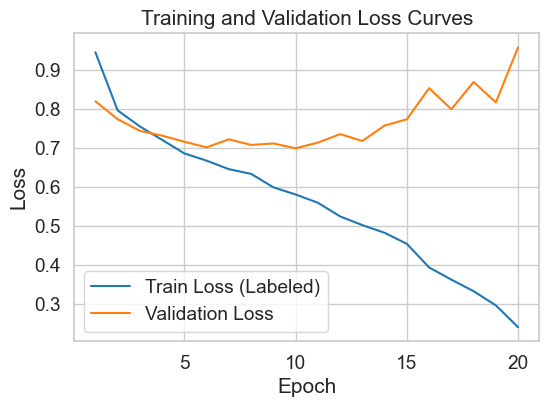

In [11]:
plot_loss_curves(train_history)

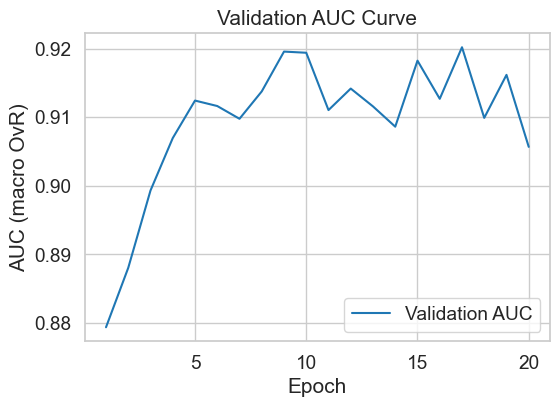

In [13]:
plot_auc_curve(train_history)

In [15]:
best = max(train_history, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best['epoch']} | Val AUC: {best['val_auc']:.4f} | Val Acc: {best['val_acc']:.4f}")

best_model_upper_bound = CNN(n_channels, n_classes)
best_model_upper_bound.load_state_dict(best['model_state'])

Best Epoch: 17 | Val AUC: 0.9202 | Val Acc: 0.7488


<All keys matched successfully>

In [17]:
test_auc = evaluate(best_model_upper_bound, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.9116


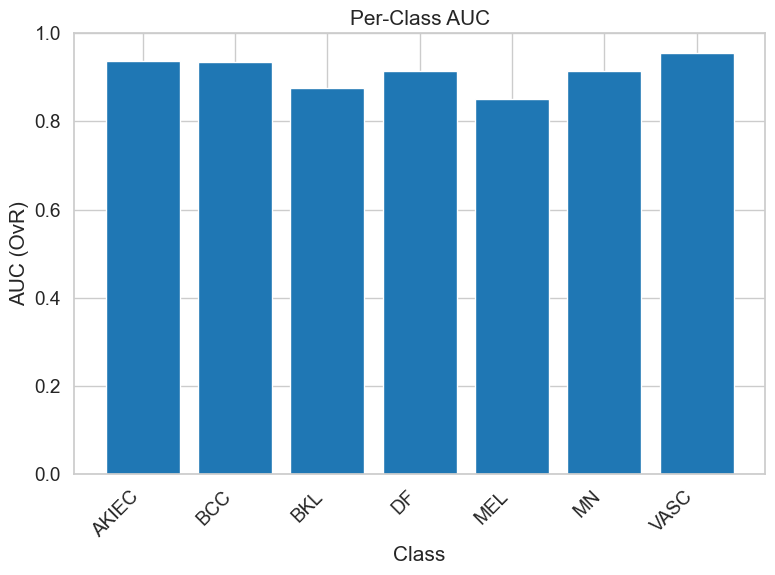

In [30]:
perclass_auc, confusion_matrix = evaluate_perclass(best_model_upper_bound, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

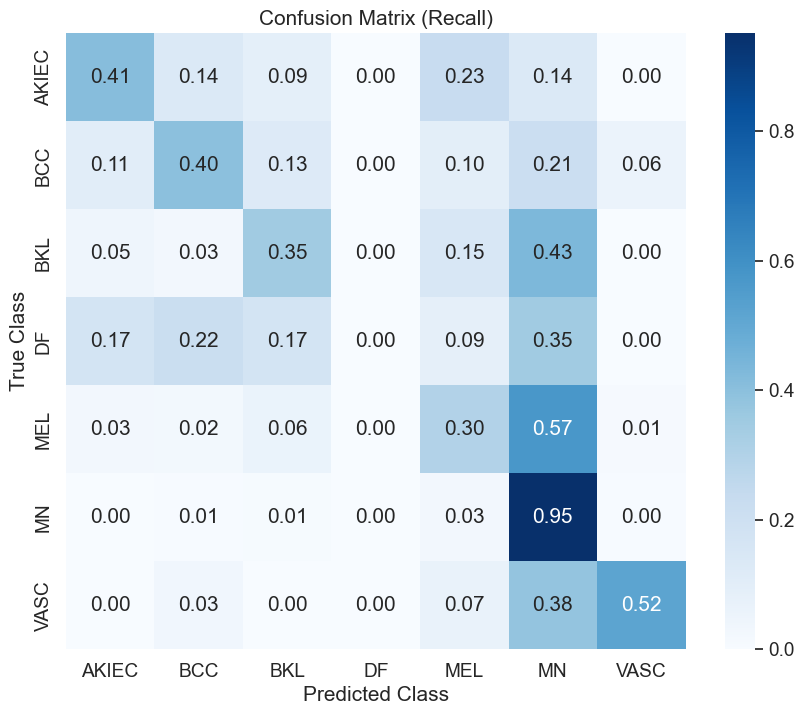

In [32]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

## Create SSL versions of the dataset

In [10]:
RANDOM_SEED = 42

In [11]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

# print(train_dataset.labels)
# print(train_dataset.imgs)
train_labels_ssl = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset = SSLDataset(train_dataset, train_labels_ssl)
train_ssl_loader = data.DataLoader(train_ssl_dataset, batch_size=BATCH_SIZE, shuffle=True)

### Define the Baseline non-Bayesian CNN

In [14]:
# define a simple CNN model
model = CNN(in_channels=n_channels, num_classes=n_classes)
    
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()

### Training Loop

In [15]:
NUM_EPOCHS = 3
lr = 0.001
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)


In [18]:
train_history = train_loop_labeled(model, train_ssl_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

100%|██████████| 55/55 [00:02<00:00, 24.58it/s]


Epoch 1/3 | Train Loss: 0.9841 | Val Loss: 0.9453 | Val Acc: 0.6690


100%|██████████| 55/55 [00:02<00:00, 24.59it/s]


Epoch 2/3 | Train Loss: 0.9296 | Val Loss: 0.9245 | Val Acc: 0.6690


100%|██████████| 55/55 [00:02<00:00, 24.51it/s]


Epoch 3/3 | Train Loss: 0.9007 | Val Loss: 0.8837 | Val Acc: 0.6710


In [19]:
train_history

[{'epoch': 1,
  'train_loss': 0.9840669722232014,
  'val_loss': 0.9452588456577936,
  'val_acc': 0.6689930209371885,
  'train_total': 3506,
  'val_total': 1003},
 {'epoch': 2,
  'train_loss': 0.9296357004525522,
  'val_loss': 0.924516993885858,
  'val_acc': 0.6689930209371885,
  'train_total': 3506,
  'val_total': 1003},
 {'epoch': 3,
  'train_loss': 0.90074626935664,
  'val_loss': 0.8836522895697939,
  'val_acc': 0.67098703888335,
  'train_total': 3506,
  'val_total': 1003}]